Trial 5 Complete [00h 00m 07s]
val_accuracy: 0.5642737746238708

Best val_accuracy So Far: 0.5642737746238708
Total elapsed time: 00h 00m 43s

Hyperparameter Search Complete!
  Best Embedding Dim  : 64
  Best LSTM Units     : 64
  Best Dropout Rate   : 0.4
  Best Learning Rate  : 0.001

Epoch 1/7
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3921 - loss: 2.5420 - val_accuracy: 0.4819 - val_loss: 2.0310
Epoch 2/7
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4727 - loss: 2.0466 - val_accuracy: 0.5053 - val_loss: 1.9386
Epoch 3/7
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4181 - loss: 2.0565 - val_accuracy: 0.4936 - val_loss: 1.8449
Epoch 4/7
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5170 - loss: 1.7838 - val_accuracy: 0.5181 - val_loss: 1.7780
Epoch 5/7
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5507 - loss: 1.6400 - val_accuracy: 0.5459 - val_loss: 1.6743
Epoch 6/7
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5733 -

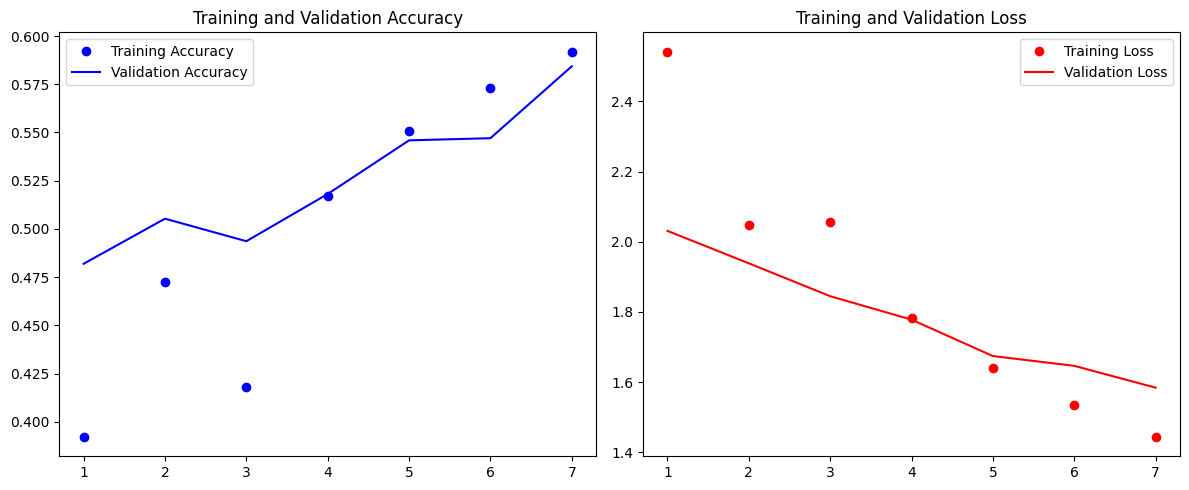


Evaluating on Test Data...
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5806 - loss: 1.6460
Test Accuracy : 58.06%
Test Loss     : 1.6460
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Classification Report (Top classes):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.13      0.44      0.21       105
           2       0.00      0.00      0.00        20
           3       0.92      0.91      0.91       813
           4       0.76      0.85      0.80       474
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00        14
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00        38
           9       0.00      0.00      0.00        25
          10       0.08      0.40      0.13        30
          11       0.00      0.00      0.00        83
          12       0.00      0.00      0.00        13
          13       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


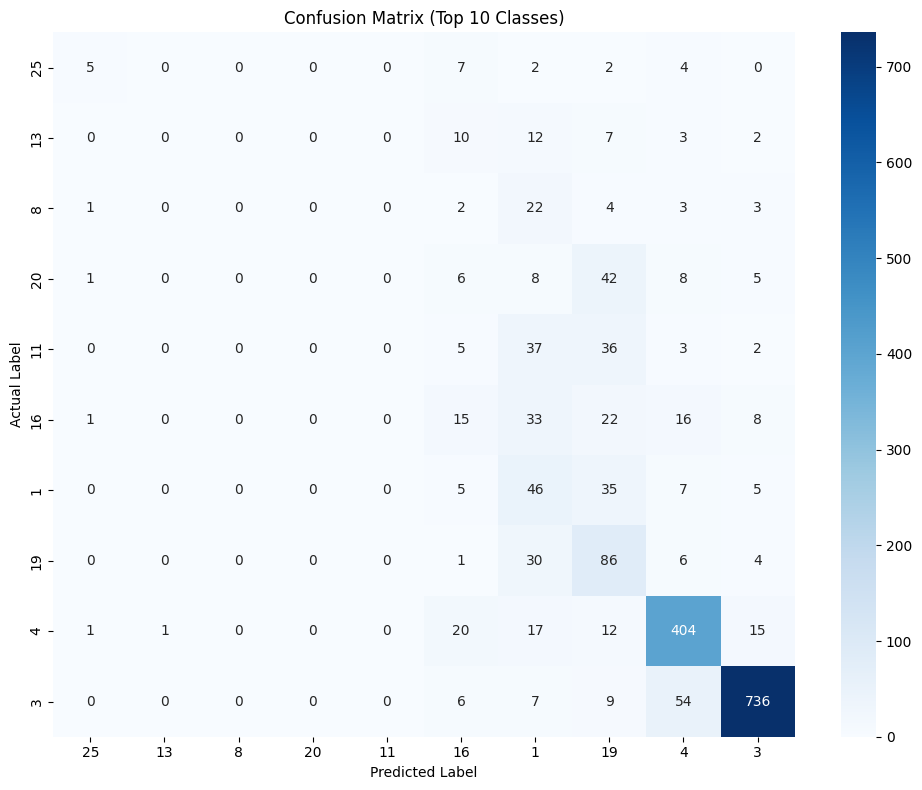

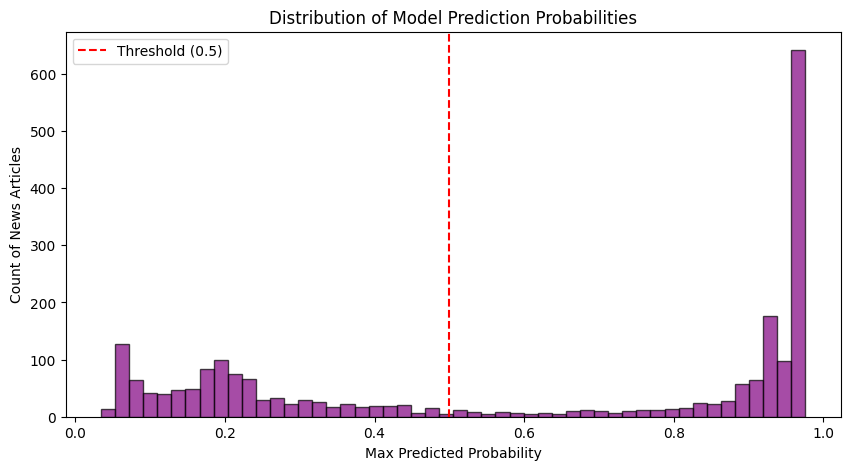

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 2us/step

Sample Predictions:

Article snippet : ...1 58 billion dlrs a and p gave no details on the expanded capital program but it did say it completed the first year of the program during 1986 a and p is 52 4 pct owned by lt of west germany reuter 3
Actual class    : 3
Predicted class : 4
Confidence      : 0.4731

Article snippet : ... philippine mills were expected to shut down at least four of the 41 mills were not working during the 1986 87 season he said we expect two or three more to follow suit during the next season reuter 3
Actual class    : 10
Predicted class : 1
Confidence      : 0.1926

Article snippet : ...ing more adjustments if gulf prices fall said no other changes in usda's price system are being planned right now we don't tinker we don't make changes and we don't make changes often he said reuter 3
Actual class    : 1
Predicted class : 1
Confidence      : 0.0885


In [ ]:
!pip install keras-tuner -q

# Step 2: Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Step 3: Configuration
MAX_FEATURES = 10000   # Top 10,000 words
MAX_LEN = 200          # Pad/truncate to 200 words
NUM_CLASSES = 46       # Reuters has 46 topic categories

# Step 4: Load Dataset
print("Loading Reuters dataset...")
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=MAX_FEATURES)
print(f"Training sequences : {len(x_train)}")
print(f"Testing sequences  : {len(x_test)}")
print(f"Number of classes  : {NUM_CLASSES}")

# Step 5: Pad Sequences
x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN)
print(f"Shape after padding - Train: {x_train.shape}, Test: {x_test.shape}")

# Step 6: Convert labels to categorical
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

# Step 7: Model builder for Keras Tuner
def build_model(hp):
    model = Sequential()
    model.add(Embedding(
        input_dim=MAX_FEATURES,
        output_dim=hp.Int('embedding_dim', min_value=32, max_value=128, step=32),
        input_length=MAX_LEN
    ))
    model.add(LSTM(
        units=hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    ))
    model.add(Dropout(
        rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    ))
    model.add(Dense(NUM_CLASSES, activation='softmax'))  # Multi-class output

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Step 8: Hyperparameter Tuning with Random Search
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='reuters_tuning_dir',
    project_name='reuters_lstm_tuning'
)

tuner.search_space_summary()

print("\nStarting Hyperparameter Search...")
tuner.search(
    x_train, y_train_cat,
    epochs=3,
    validation_split=0.2,
    batch_size=64
)

# Step 9: Best Hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Hyperparameter Search Complete!
  Best Embedding Dim  : {best_hps.get('embedding_dim')}
  Best LSTM Units     : {best_hps.get('lstm_units')}
  Best Dropout Rate   : {best_hps.get('dropout_rate')}
  Best Learning Rate  : {best_hps.get('learning_rate')}
""")

# Step 10: Final Training with Best Hyperparameters
model = tuner.hypermodel.build(best_hps)
history = model.fit(
    x_train, y_train_cat,
    epochs=7,
    validation_split=0.2,
    batch_size=64
)

# Step 11: Training & Validation Curves
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc,     'bo', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'b',  label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss,     'ro', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r',  label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Step 12: Test Evaluation
print("\nEvaluating on Test Data...")
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# Step 13: Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 14: Classification Report
print("\nClassification Report (Top classes):")
print(classification_report(y_test, y_pred))

# Step 15: Confusion Matrix (Top 10 most frequent classes only — 46 is too many to display)
top_classes = np.argsort(np.bincount(y_test))[-10:]
mask = np.isin(y_test, top_classes)
cm = confusion_matrix(y_test[mask], y_pred[mask], labels=top_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_classes, yticklabels=top_classes)
plt.title('Confusion Matrix (Top 10 Classes)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# Step 16: Prediction Probability Distribution
plt.figure(figsize=(10, 5))
max_probs = np.max(y_pred_probs, axis=1)
plt.hist(max_probs, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title('Distribution of Model Prediction Probabilities')
plt.xlabel('Max Predicted Probability')
plt.ylabel('Count of News Articles')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.legend()
plt.show()

# Step 17: Sample Predictions
word_index = reuters.get_word_index()
index_word = {v: k for k, v in word_index.items()}

print("\nSample Predictions:")
for i in range(3):
    review_words = ' '.join([index_word.get(idx - 3, '?') for idx in x_test[i] if idx > 3])
    print(f"\nArticle snippet : ...{review_words[-200:]}")
    print(f"Actual class    : {y_test[i]}")
    print(f"Predicted class : {y_pred[i]}")
    print(f"Confidence      : {max_probs[i]:.4f}")